In [ ]:
### Imports ###

import torch
import rasterio
import numpy as np
import torch.nn as nn
import glob
import re
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Definition of the Neural Net

class DamCNN(nn.Module):
    def __init__(self):
        super(DamCNN, self).__init__()

        # Block 1: Input is (1, 500, 500) -> Output is (16, 250, 250)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: Input is (16, 250, 250) -> Output is (32, 125, 125)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 3: Input is (32, 125, 125) -> Output is (64, 62, 62)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 4: Input is (64, 62, 62) -> Output is (128, 31, 31)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Destroy spatial memorization.
        # It takes 128 maps of 31x31 pixels and turns them into exactly 128 numbers.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(128, 256)
        self.relu_fc = nn.ReLU()
        
        # Final layer outputs a single number (the volume)
        self.fc2 = nn.Linear(in_features=256, out_features=1)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))
        
        x = self.global_pool(x)
        x = self.flatten(x)
        
        x = self.relu_fc(self.fc1(x))
        x = self.fc2(x)
        
        return x.view(-1, 1)

def predict_volume(image_path, model_path, loss_mode='mse'):
    # Load the model
    model = DamCNN()
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()

    # Preprocess the raw image
    with rasterio.open(image_path) as src:
        img = src.read(1)
    
    img = np.nan_to_num(img, nan=-1.0)
    img = np.clip(img, -1.0, 1.0)
    tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()
    
    # Pad to 500x500
    pad_h = 500 - tensor.shape[2]
    pad_w = 500 - tensor.shape[3]
    tensor = F.pad(tensor, (0, pad_w, 0, pad_h), value=-1.0)

    # 4. PREDICT
    with torch.no_grad():
        prediction = model(tensor)
        if(loss_mode=='log_mse'):
            real_volume = np.expm1(prediction.item())
        else:
            real_volume = prediction.item() * 300.0
        
    return real_volume

In [ ]:
# Generate prediction for each raster in
# the Terradets folder.

tiff_files_terradets = glob.glob("../data/terradets/*.tiff")

predictions = []

for file in tiff_files_terradets:
    get_date = re.search(r'(\d{4}-\d{2}-\d{2})', file).group(1)
    result_mse = predict_volume(file, "../models/dam_model_mse.pth", loss_mode='mse')
    result_mape = predict_volume(file, "../models/dam_model_mape.pth", loss_mode='mape')
    result_log_mse = predict_volume(file, "../models/dam_model_log_mse.pth", loss_mode='log_mse')

    predictions.append({
        "date": get_date,
        "prediction_mse": result_mse,
        "prediction_mape": result_mape,
        "prediction_log_mse": result_log_mse
    })

# Save results

pd.DataFrame(predictions).to_csv('../data/terradets_predictions.csv', index=False)

In [133]:
# Join predictions and labels

volume_pred = pd.read_csv('../data/terradets_predictions.csv')
labels = pd.read_csv('../data/terradets/volume_terradets/volume_terradets.csv', sep=';')
volume_pred['date'] = pd.to_datetime(volume_pred['date'])
labels['FECHA_GRUPO'] = pd.to_datetime(labels['FECHA_GRUPO'], dayfirst=True)
volume_pred['hybrid_savgol_on_mape'] = savgol_filter(volume_pred['prediction_mape'], window_length=11, polyorder=2)
volume_pred.bfill(inplace=True)
volume_pred.ffill(inplace=True)

pred_label_joined = pd.merge(volume_pred, labels, how='left', left_on='date', right_on='FECHA_GRUPO')

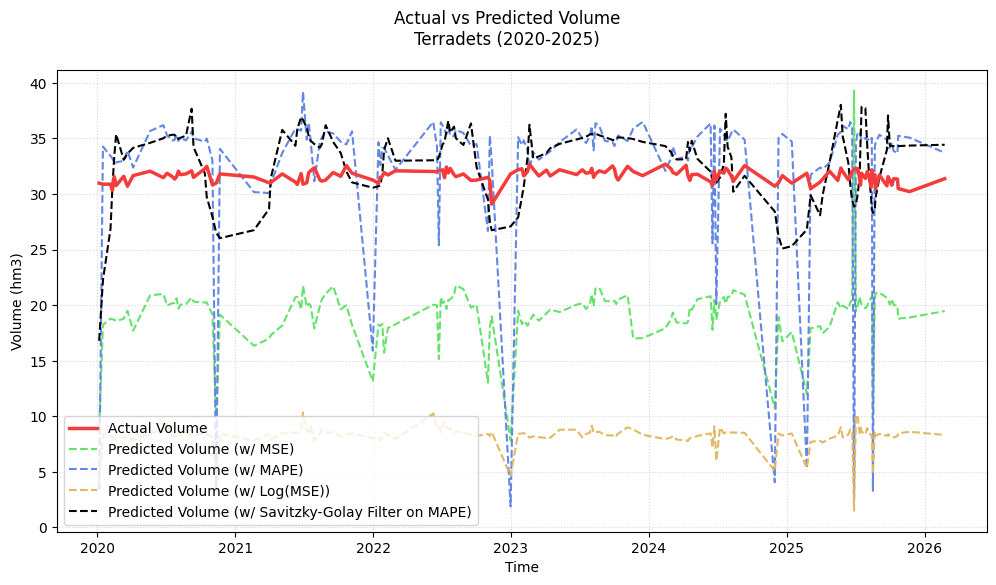

In [134]:
# Generate visualization

plt.figure(figsize=(12,6))
plt.plot(pred_label_joined['date'], pred_label_joined['ACUMULADO (hm3)'], color="#F43C3C", label='Actual Volume', zorder=10, linewidth=2.5)
plt.plot(pred_label_joined['date'], pred_label_joined['prediction_mse'], color="#63E369", label='Predicted Volume (w/ MSE)', linestyle='--')
plt.plot(pred_label_joined['date'], pred_label_joined['prediction_mape'], color="#6387E3", label='Predicted Volume (w/ MAPE)', linestyle='--')
plt.plot(pred_label_joined['date'], pred_label_joined['prediction_log_mse'], color="#e3b863", label='Predicted Volume (w/ Log(MSE))', linestyle='--')
plt.plot(pred_label_joined['date'], pred_label_joined['hybrid_savgol_on_mape'], color="#000000", label='Predicted Volume (w/ Savitzky-Golay Filter on MAPE)', linestyle='--')


plt.xlabel('Time')
plt.ylabel('Volume (hm3)')
plt.suptitle('Actual vs Predicted Volume\nTerradets (2020-2025)')


plt.grid(True, alpha=0.5, linestyle=':')

plt.legend(loc='lower left')
plt.savefig('../output/figs/prediction_vs_labels_terradets', dpi=800)
plt.show()